# 01 — EDA & Data Cleaning (output.json + geo enrichment)

Uses the full 176K-record `output.json` merged with geo data from `final_dataset.json`.
Produces `data/processed.csv` for model training.

In [1]:
import json, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUT_PATH = Path('../data/output.json')
GEO_PATH    = Path('../data/final_dataset.json')
OUT_PATH    = Path('../data/processed.csv')
FEAT_PATH   = Path('../data/feature_list.json')

# output.json = two concatenated JSON arrays — use incremental decoder
decoder = json.JSONDecoder()
text = OUTPUT_PATH.read_text(encoding='utf-8').strip()
records, pos = [], 0
while pos < len(text):
    while pos < len(text) and text[pos] in ' \n\r\t': pos += 1
    if pos >= len(text): break
    chunk, end = decoder.raw_decode(text, pos)
    records.extend(chunk)
    pos = end

df = pd.DataFrame(records)
print(f'Loaded {len(df):,} records. Columns: {df.columns.tolist()}')

Loaded 176,910 records. Columns: ['Url', 'Openfire', 'Furnished', 'Terrace', 'Garden', 'PropertyId', 'TypeOfProperty', 'PostalCode', 'SubtypeOfProperty', 'TypeOfSale', 'Price', 'Kitchen', 'StateOfBuilding', 'Heating', 'Bedrooms', 'SurfaceOfGood', 'SwimmingPool', 'ConstructionYear', 'GardenArea', 'LivingArea', 'NumberOfFacades']


## 1. Filter — sales only, valid price

After filters: 92,544 records (removed 84,366)


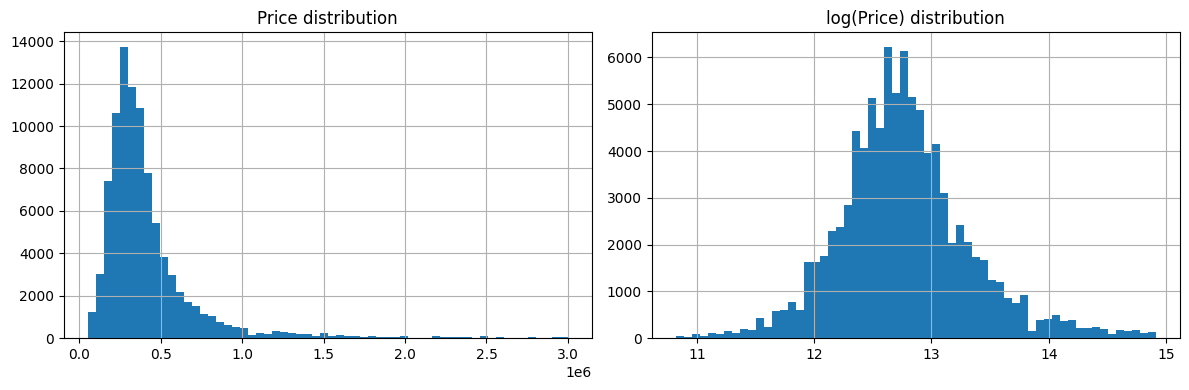

In [2]:
before = len(df)
df = df[df['TypeOfSale'] == 1]          # 1 = sale, 2 = rent
df = df.dropna(subset=['Price'])
df = df.dropna(subset=['LivingArea'])

PRICE_MIN, PRICE_MAX = 50_000, 3_000_000
df = df[(df['Price'] >= PRICE_MIN) & (df['Price'] <= PRICE_MAX)]
df = df[df['LivingArea'].between(15, 2000)]

print(f'After filters: {len(df):,} records (removed {before - len(df):,})')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Price'].hist(bins=60, ax=axes[0])
axes[0].set_title('Price distribution')
np.log1p(df['Price']).hist(bins=60, ax=axes[1])
axes[1].set_title('log(Price) distribution')
plt.tight_layout()
plt.show()

## 2. Rename columns to standard names

In [3]:
df = df.rename(columns={
    'Bedrooms':    'BedroomCount',
    'SurfaceOfGood': 'SurfaceOfPlot',
    'Openfire':    'Fireplace',
})
df['PropertyId'] = df['PropertyId'].astype(str)
print('Columns after rename:', df.columns.tolist())

Columns after rename: ['Url', 'Fireplace', 'Furnished', 'Terrace', 'Garden', 'PropertyId', 'TypeOfProperty', 'PostalCode', 'SubtypeOfProperty', 'TypeOfSale', 'Price', 'Kitchen', 'StateOfBuilding', 'Heating', 'BedroomCount', 'SurfaceOfPlot', 'SwimmingPool', 'ConstructionYear', 'GardenArea', 'LivingArea', 'NumberOfFacades']


## 3. Add Latitude, Longitude & Region from final_dataset.json

In [4]:
# Load geo file and build PostalCode → centroid + Region lookup
df_geo = pd.read_json(GEO_PATH)
df_geo['PropertyId'] = df_geo['PropertyId'].astype(str)
df_geo['Region'] = df_geo['Region'].replace({'Wallonie': 'Wallonia'})

# Property-level merge (best accuracy)
geo_cols = df_geo[['PropertyId', 'Latitude', 'Longitude', 'Region']].copy()
df = df.merge(geo_cols, on='PropertyId', how='left')
print(f'After property merge — lat/lon missing: {df["Latitude"].isna().sum():,}')

# PostalCode-level fallback for unmatched properties
df['PostalCode'] = pd.to_numeric(df['PostalCode'], errors='coerce').fillna(1000).astype(int)
postal_geo = (
    df_geo
    .assign(PostalCode=pd.to_numeric(df_geo['PostalCode'], errors='coerce'))
    .dropna(subset=['Latitude','Longitude'])
    .groupby('PostalCode')
    .agg(lat_median=('Latitude','median'), lon_median=('Longitude','median'),
         region_mode=('Region', lambda x: x.mode().iloc[0] if len(x.mode()) else 'Flanders'))
    .reset_index()
)

missing_mask = df['Latitude'].isna()
df_missing = df[missing_mask].merge(
    postal_geo[['PostalCode','lat_median','lon_median','region_mode']],
    on='PostalCode', how='left'
)
df.loc[missing_mask, 'Latitude']  = df_missing['lat_median'].values
df.loc[missing_mask, 'Longitude'] = df_missing['lon_median'].values
df.loc[missing_mask & df['Region'].isna(), 'Region'] = df_missing['region_mode'].values

# Final fallback — Belgian centroid
df['Latitude']  = df['Latitude'].fillna(50.5)
df['Longitude'] = df['Longitude'].fillna(4.5)
df['Region']    = df['Region'].fillna('Flanders')

print(f'Lat/lon missing after all fallbacks: {df["Latitude"].isna().sum()}')
print('Region distribution:', df['Region'].value_counts().to_dict())

After property merge — lat/lon missing: 92,394
Lat/lon missing after all fallbacks: 0
Region distribution: {'Flanders': 58082, 'Wallonia': 24645, 'Brussels': 9817}


## 4. Fill missing values

In [5]:
df['BedroomCount']    = df['BedroomCount'].fillna(2).clip(lower=0).astype(int)
df['NumberOfFacades'] = df['NumberOfFacades'].fillna(2).clip(1, 4).astype(int)
df['SurfaceOfPlot']   = df['SurfaceOfPlot'].fillna(0)
df['GardenArea']      = df['GardenArea'].fillna(0)

# Boolean features — fill False
for col in ['Fireplace', 'Furnished', 'Terrace', 'Garden', 'SwimmingPool']:
    df[col] = df[col].fillna(False).astype(int)

# Kitchen — binary: 1 if any kitchen, 0 if null or 'not installed'
df['Kitchen'] = df['Kitchen'].apply(
    lambda x: 0 if pd.isna(x) or str(x).lower() in ('not installed', 'usa uninstalled') else 1
)

print('Missing after fill:')
print(df[['BedroomCount','NumberOfFacades','SurfaceOfPlot','GardenArea','Kitchen']].isna().sum())

Missing after fill:
BedroomCount       0
NumberOfFacades    0
SurfaceOfPlot      0
GardenArea         0
Kitchen            0
dtype: int64


## 5. Categorical encoding

In [6]:
# TypeOfProperty: 1=HOUSE, 2=APARTMENT
df['TypeOfProperty_Num'] = df['TypeOfProperty'].map({1: 0, 2: 1}).fillna(0).astype(int)

# Region
region_map = {'Flanders': 0, 'Wallonia': 1, 'Brussels': 2}
df['Region_Num'] = df['Region'].map(region_map).fillna(0).astype(int)

# StateOfBuilding — ordinal (better condition = lower number)
state_map = {
    'as new': 0, 'just renovated': 0,
    'good': 1,
    'to be done up': 2,
    'to renovate': 3,
    'to restore': 4,
}
df['StateOfBuilding_Num'] = df['StateOfBuilding'].str.lower().map(state_map).fillna(1).astype(int)

# Heating
heating_map = {'gas': 0, 'fueloil': 1, 'electric': 2, 'pellet': 3, 'wood': 4, 'carbon': 5, 'solar': 6}
df['HeatingType_Num'] = df['Heating'].str.lower().map(heating_map).fillna(0).astype(int)

print('Encoding done.')
print('StateOfBuilding_Num:', df['StateOfBuilding_Num'].value_counts().to_dict())
print('HeatingType_Num:', df['HeatingType_Num'].value_counts().to_dict())

Encoding done.
StateOfBuilding_Num: {1: 64971, 0: 16263, 3: 6123, 2: 4838, 4: 349}
HeatingType_Num: {0: 77826, 1: 8723, 2: 4959, 3: 603, 4: 214, 6: 139, 5: 80}


## 6. Feature engineering

In [7]:
# ConstructionYear → HouseAge
year_median = df['ConstructionYear'].median()
df['ConstructionYear'] = df['ConstructionYear'].fillna(year_median).clip(1800, 2025).astype(int)
df['HouseAge'] = (2025 - df['ConstructionYear']).clip(lower=0)

# Distance to Brussels (Haversine)
_LAT_BXL, _LON_BXL = 50.8503, 4.3517
dlat = np.radians(df['Latitude'] - _LAT_BXL)
dlon = np.radians(df['Longitude'] - _LON_BXL)
a = np.sin(dlat/2)**2 + np.cos(np.radians(df['Latitude'])) * np.cos(np.radians(_LAT_BXL)) * np.sin(dlon/2)**2
df['DistanceToBrussels'] = 6371.0 * 2 * np.arcsin(np.sqrt(a))

# RoomCount — not in output.json, estimate from BedroomCount
df['RoomCount'] = (df['BedroomCount'] + 2).clip(lower=1)  # conservative estimate
df['BedroomRatio'] = df['BedroomCount'] / df['RoomCount']

# Municipality avg price per m²
postal_avg = (
    df.groupby('PostalCode')['Price']
    .median()
    .div(df.groupby('PostalCode')['LivingArea'].median())
    .rename('MunicipalityAvgPricePerM2')
)
df = df.join(postal_avg, on='PostalCode')
df['MunicipalityAvgPricePerM2'] = df['MunicipalityAvgPricePerM2'].fillna(df['MunicipalityAvgPricePerM2'].median())

print('Feature engineering done.')
print(f'HouseAge range: {df["HouseAge"].min()}–{df["HouseAge"].max()}')
print(f'DistanceToBrussels range: {df["DistanceToBrussels"].min():.1f}–{df["DistanceToBrussels"].max():.1f} km')

Feature engineering done.
HouseAge range: 0–225
DistanceToBrussels range: 0.3–178.2 km


In [8]:
STATBEL_PATH = Path('../data/statbel_features.csv')
if STATBEL_PATH.exists():
    df_statbel = pd.read_csv(STATBEL_PATH)
    df_statbel['PostalCode'] = df_statbel['PostalCode'].astype(int)
    df = df.merge(df_statbel, on='PostalCode', how='left')
    df['MedianIncome']      = df['MedianIncome'].fillna(df['MedianIncome'].median())
    df['PopulationDensity'] = df['PopulationDensity'].fillna(df['PopulationDensity'].median())
    print('Statbel joined. Median income by region:')
    print(df.groupby('Region')[['MedianIncome','PopulationDensity']].median().round(0).to_string())
else:
    print('statbel_features.csv not found -- run data/fetch_statbel.py first')
    df['MedianIncome']      = 25000
    df['PopulationDensity'] = 400


Statbel joined. Median income by region:
          MedianIncome  PopulationDensity
Region                                   
Brussels       33635.0             7765.0
Flanders       40766.0              703.0
Wallonia       36455.0              495.0


## 7. Correlation with Price (top features)

In [9]:
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()['Price'].drop('Price').abs().sort_values(ascending=False)
print('Top 20 correlations with Price:')
print(corr.head(20).round(3).to_string())

Top 20 correlations with Price:
LivingArea                   0.539
MunicipalityAvgPricePerM2    0.414
RoomCount                    0.406
BedroomCount                 0.406
BedroomRatio                 0.331
MedianIncome                 0.288
SwimmingPool                 0.231
NumberOfFacades              0.175
Latitude                     0.163
TypeOfProperty               0.156
TypeOfProperty_Num           0.156
StateOfBuilding_Num          0.154
DistanceToBrussels           0.088
Longitude                    0.084
Garden                       0.049
Kitchen                      0.049
HeatingType_Num              0.046
HouseAge                     0.045
ConstructionYear             0.045
PostalCode                   0.036


## 8. Define feature set & save

In [10]:
feature_cols = [
    # Core property
    'LivingArea', 'BedroomCount', 'NumberOfFacades', 'SurfaceOfPlot',
    # Location
    'PostalCode', 'Latitude', 'Longitude', 'DistanceToBrussels', 'MunicipalityAvgPricePerM2',
    # Building
    'ConstructionYear', 'HouseAge', 'StateOfBuilding_Num', 'HeatingType_Num',
    # Amenities
    'Garden', 'GardenArea', 'Terrace', 'SwimmingPool', 'Fireplace', 'Furnished', 'Kitchen',
    # Categorical encodings
    'TypeOfProperty_Num', 'Region_Num',
    # Derived
    'BedroomRatio',
    # Statbel municipal socio-economics
    'MedianIncome', 'PopulationDensity',
]

# Keep only rows where all features are non-null
df_model = df[feature_cols + ['Price']].dropna()
print(f'Final dataset: {len(df_model):,} rows x {len(feature_cols)} features')
print('Features:', feature_cols)

# Save
FEAT_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(FEAT_PATH, 'w') as f:
    json.dump(feature_cols, f, indent=2)

api_feat = Path('../immo_api/models/feature_list.json')
with open(api_feat, 'w') as f:
    json.dump(feature_cols, f, indent=2)

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df_model.to_csv(OUT_PATH, index=False)
print(f'Saved → {OUT_PATH}')

Final dataset: 92,544 rows x 25 features
Features: ['LivingArea', 'BedroomCount', 'NumberOfFacades', 'SurfaceOfPlot', 'PostalCode', 'Latitude', 'Longitude', 'DistanceToBrussels', 'MunicipalityAvgPricePerM2', 'ConstructionYear', 'HouseAge', 'StateOfBuilding_Num', 'HeatingType_Num', 'Garden', 'GardenArea', 'Terrace', 'SwimmingPool', 'Fireplace', 'Furnished', 'Kitchen', 'TypeOfProperty_Num', 'Region_Num', 'BedroomRatio', 'MedianIncome', 'PopulationDensity']


Saved → ..\data\processed.csv
